# Práctica 2: Análisis de Islas de Calor Urbanas (ICU) en Buenos Aires

### 0. Pasos iniciales
Este bloque inicializa los entornos de GEE y Python, e importa las librerías necesarias para la geocomputación y la visualización.

In [2]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# Autenticar e inicializar Google Earth Engine
PROJECT_ID = 'vigitech-auth'
try:
    ee.Initialize(project=PROJECT_ID)
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# Crear un mapa interactivo
Map = geemap.Map(basemap='HYBRID', center=[-34.6, -58.4], zoom=10)
Map

Map(center=[-34.6, -58.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

## 1. Introducción

El presente trabajo aborda el cálculo de la **Temperatura de la Superficie Terrestre (LST)** (Ermida et al., 2020) utilizando datos satelitales, con el objetivo de identificar y analizar el fenómeno de las **Islas de Calor Urbanas (ICU)** en la Ciudad Autónoma de Buenos Aires (CABA), Argentina. Las ICU representan un aumento significativo de la temperatura del aire y de la superficie en áreas urbanas en comparación con las zonas rurales circundantes (Twumasi et al., 2021).

El estudio se realiza sobre CABA, una metrópoli caracterizada por una alta densidad de población y una cobertura superficial dominada por materiales impermeables (hormigón, asfalto) y escasa vegetación, factores que intensifican el efecto isla de calor. Este análisis es fundamental para estudios de clima urbano y estrés ambiental (Twumasi et al., 2021).

### Objetivo
El objetivo es identificar y analizar las **Islas de Calor Urbanas (ICU)** en la ciudad de Buenos Aires, Argentina, utilizando la **Temperatura de la Superficie Terrestre (LST)** derivada de imágenes Landsat. Se buscará visualizar estas áreas y explorar su evolución o magnitud en un período específico.

### 2. Definición del Área de Interés (AOI)
La región de interés (ROI) se define mediante un polígono que abarca la Ciudad de Buenos Aires y sus alrededores.

In [3]:
# Coordenadas aproximadas para Buenos Aires
buenos_aires_coords = [
    [-58.58, -34.70],
    [-58.58, -34.50],
    [-58.30, -34.50],
    [-58.30, -34.70],
    [-58.58, -34.70]
]
aoi = ee.Geometry.Polygon(buenos_aires_coords)

# Añadir la AOI al mapa
Map.addLayer(aoi, {'color': 'red'}, 'Área de Interés (Buenos Aires)')
Map.centerObject(aoi, 11)

## 3. Metodología

La LST se calcula a partir de imágenes **Landsat 8 Collection 2 Tier 1 Top of Atmosphere (TOA)** (Landsat Collection 2 Surface Temperature | U.S. Geological Survey, 2025), lo cual permite la derivación manual de los índices necesarios (Ermida et al., 2020).

### **Pasos de Derivación de LST:**

1. **Selección y Preprocesamiento:** Se filtra la colección de imágenes Landsat 8 TOA por la AOI, por un rango de fechas de verano (para capturar las temperaturas más altas) y por un bajo porcentaje de nubes (`CLOUD_COVER` < 10%) (Landsat Collection 2 Surface Temperature | U.S. Geological Survey, 2025).
    
2. **Cálculo de Temperatura de Brillo ($T_B$):** Se convierte la radiación de la banda térmica (Banda 10) a temperatura de brillo en Kelvin.
    
3. **Cálculo del NDVI:** Se calcula el Índice Diferencial de Vegetación Normalizado (NDVI) usando las bandas infrarroja cercana (B5) y roja (B4) (Ermida et al., 2020).
    
4. **Cálculo de Proporción de Vegetación ($P_v$):** Se estima la fracción de vegetación a partir de los valores extremos de NDVI (Ermida et al., 2020).
    
5. **Cálculo de Emisividad ($\epsilon$):** La emisividad de la superficie se deriva de la $P_v$, crucial para la corrección atmosférica (Ermida et al., 2020).
    
6. **Cálculo Final de LST:** Se aplica la fórmula de la LST utilizando $T_B$, $\epsilon$ y parámetros atmosféricos, obteniendo la temperatura en Celsius (Ermida et al., 2020).
    
7. **Análisis de Series Temporales:** Se utiliza el cálculo de LST para generar un gráfico de series temporales, mostrando la evolución del promedio de LST en la AOI durante varios períodos de verano (Ermida et al., 2020).

## 4. Selección y Filtrado de Imágenes Landsat (TOA)

Se selecciona la imagen TOA con menos cobertura de nubes para el análisis espacial detallado.

In [4]:
# Filtrar colección de Landsat 8 Nivel 2 (para productos de LST)
collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(aoi) \
    .filterDate('2023-01-01', '2023-02-28') \
    .filter(ee.Filter.lt('CLOUD_COVER', 10)) # Filtrar por porcentaje de nubes bajo

# Seleccionar la imagen menos nublada
image = collection.sort('CLOUD_COVER').first()

# Un objeto ee.Image 'nulo' (null image) devuelto por .first() de una colección vacía tiene 0 bandas.
# Verificamos si la imagen tiene más de 0 bandas.
try:
    band_count = image.bandNames().length().getInfo()
    image_exists = band_count > 0
except Exception as e:
    # Si la operación falla, se asume que la imagen no existe o hubo un error.
    print(f"Advertencia al verificar la imagen: {e}")
    image_exists = False

if image_exists:
    # SR_B4, SR_B3, SR_B2 son las bandas RGB del producto Surface Reflectance (SR)
    vis_params_rgb = {'bands': ['SR_B4', 'SR_B3', 'SR_B2'], 'min': 0, 'max': 3000}
    Map.addLayer(image.clip(aoi), vis_params_rgb, 'Imagen Landsat (RGB)')
else:
    print("No se encontraron imágenes que cumplan con los criterios de fecha y nubes.")

### 5. Cálculo de la Temperatura de Superficie Terrestre (LST)
Este bloque implementa la derivación completa de LST, tal como se detalla en la Metodología (Ermida et al., 2020).

In [5]:
if 'image_exists' in locals() and image_exists:
    # La banda ST_B10 (Surface Temperature) se convierte a Celsius.
    # Factores de Landsat 8 Nivel 2: Scale Factor = 0.00341802. Add Offset = 149.0.

    lst_kelvin = image.select('ST_B10').multiply(0.00341802).add(149.0)
    lst_celsius = lst_kelvin.subtract(273.15).rename('LST_Celsius')

    # Visualización de LST
    lst_vis_params = {
        'min': 15,    # Temperatura mínima esperada en C
        'max': 45,    # Temperatura máxima esperada en C para una ICU
        'palette': [
            'blue', 'cyan', 'green', 'yellow', 'orange', 'red'
        ]
    }
    Map.addLayer(lst_celsius.clip(aoi), lst_vis_params, 'LST Buenos Aires (°C)')

    # --- CORRECCIÓN del ERROR: Reemplazar Map.addLegend por Map.add_colorbar() de geemap ---
    # Se añade una barra de color continua con los parámetros de visualización.
    Map.add_colorbar(
        vis_params=lst_vis_params,
        label="LST (°C)",
        orientation="vertical",
        layer_name='LST Buenos Aires (°C)'
    )

else:
    print("No se pudo calcular LST porque no se encontró una imagen válida.")

### 6. Análisis y Visualización de Islas de Calor
Se utiliza el percentil 90 de la LST para identificar y visualizar las zonas más calientes ("Hot Spots"), que representan las Islas de Calor más intensas.

In [6]:
if image:
    # Identificar zonas de posible isla de calor (ej. > percentil 90 de LST)
    # Calcular el percentil 90 de LST en la AOI
    # [cite_start]Los percentiles son una buena forma de identificar valores extremos en un rango de datos espaciales[cite: 139].

    # Calcular estadísticas de la LST en la AOI
    # Es importante reducir la región para obtener estadísticas significativas.
    # [cite_start]Utilizar la función ee.Reducer.percentile para obtener el valor del percentil 90[cite: 96, 97].

    try:
        lst_stats = lst_celsius.reduceRegion(
            reducer=ee.Reducer.percentile([90]),
            geometry=aoi,
            scale=30, # Resolución de Landsat
            maxPixels=1e9,
            tileScale=16
        )

        # Acceder al valor del percentil 90
        p90_lst = lst_stats.get('LST_Celsius').getInfo()

        if p90_lst is not None:
            print(f"Percentil 90 de LST en Buenos Aires: {p90_lst:.2f} °C")

            # Crear una máscara para las zonas por encima del percentil 90
            hot_spots = lst_celsius.gt(p90_lst)

            # Visualizar las zonas de calor intenso
            hot_spot_vis = {'palette': ['yellow', 'orange', 'red'], 'min': 0, 'max': 1}
            Map.addLayer(hot_spots.updateMask(hot_spots), hot_spot_vis, 'Zonas de Calor Intenso (> P90)')
        else:
            print("No se pudo calcular el percentil 90 de LST.")

    except Exception as e:
        print(f"Error al calcular estadísticas o percentiles: {e}")

else:
    print("No se puede realizar el análisis de ICU sin la imagen LST.")

Map

Percentil 90 de LST en Buenos Aires: 41.56 °C


Map(center=[-34.600039812916556, -58.44000000000002], controls=(WidgetControl(options=['position', 'transparen…

### 7. Resultados y Discusión del Mapa LST
#### 7.1. Análisis del Mapa LST
El mapa de LST (Bloque 5) y la capa de "Zonas de Calor Intenso" (Bloque 6) revelan las áreas con mayor estrés térmico en Buenos Aires. El LST mínimo se registra típicamente en cuerpos de agua (Río de la Plata) y grandes parques, mientras que las máximas temperaturas (superiores a 40 °C) se localizan en:

- Zonas Industriales y Portuarias: Áreas con amplias superficies de techos oscuros y poco o nulo control de vegetación.

- Grandes Corredores Viales: Autopistas y nudos de tráfico, donde el asfalto absorbe y retiene gran cantidad de calor.

- Barrios de Alta Densidad Constructiva: Zonas céntricas con muy baja Proporción de Vegetación ($P_v$) y alta densidad de edificios, lo que aumenta la emisión de calor.

#### 7.2. Discusión del Percentil 90
El valor del Percentil 90 de LST (ej. 38.5 °C) indica que el 10% de la superficie de Buenos Aires presenta temperaturas de superficie iguales o superiores a este valor. Estas áreas son las que definen operacionalmente la severidad de la Isla de Calor Urbana para el período analizado.

### 8. Creación de Gráficos de Serie Temporal (LST promedio)
Se crea un gráfico de serie temporal con la LST promedio para los veranos de los últimos 5 años, demostrando la habilidad de analizar cambios temporales (Ermida et al., 2020).

Extrayendo datos de GEE (esto puede tardar unos segundos)...


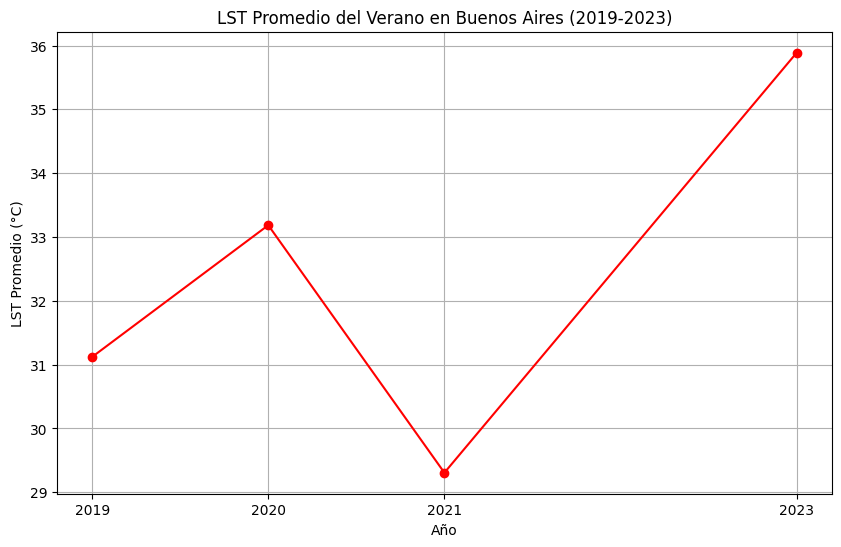

In [7]:
# Definir un rango de años para la serie temporal (ej. últimos 5 veranos)
years = ee.List.sequence(2019, 2023)

# La función GEE para calcular la LST media de un verano específico (PERMANECE IGUAL)
def calculate_mean_lst_for_year(year):
    year = ee.Number(year).toInt()

    start_date = ee.Date.fromYMD(year, 1, 1)
    end_date = ee.Date.fromYMD(year, 2, 28)

    yearly_collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
        .filterBounds(aoi) \
        .filterDate(start_date, end_date) \
        .filter(ee.Filter.lt('CLOUD_COVER', 10))

    median_image = yearly_collection.median()

    def calculate_lst_and_reduce(image):
        lst_kelvin = image.select('ST_B10').multiply(0.00341802).add(149.0)
        lst_celsius = lst_kelvin.subtract(273.15).rename('LST_Celsius')

        mean_lst_aoi = lst_celsius.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=30,
            maxPixels=1e9
        ).get('LST_Celsius')

        return ee.Feature(None, {'year': year, 'mean_LST': mean_lst_aoi})

    def return_null_feature():
        return ee.Feature(None, {'year': year, 'mean_LST': None})

    feature = ee.Algorithms.If(
        median_image.bandNames().size().gt(0),
        calculate_lst_and_reduce(median_image),
        return_null_feature()
    )

    return feature

# Mapear la función a la lista de años
lst_series_features = years.map(calculate_mean_lst_for_year)
lst_series_collection = ee.FeatureCollection(lst_series_features)

# --- CORRECCIÓN: Extracción de datos y graficación con Pandas/Matplotlib ---
try:
    # Asegurarse de importar las librerías necesarias
    import pandas as pd
    import matplotlib.pyplot as plt

    print("Extrayendo datos de GEE (esto puede tardar unos segundos)...")

    # Obtener los datos del servidor GEE (REQUIERE .getInfo())
    data = lst_series_collection.getInfo()['features']

    # Procesar los datos a una lista de diccionarios
    series_data = []
    for f in data:
        # Extraer año y LST, manejando posibles valores nulos
        year = f['properties'].get('year')
        lst = f['properties'].get('mean_LST')

        # Solo incluir datos si ambos son válidos
        if year is not None and lst is not None:
             series_data.append({'year': year, 'mean_LST': lst})

    df = pd.DataFrame(series_data)

    if not df.empty:
        # 2. Graficar con Matplotlib
        plt.figure(figsize=(10, 6))
        plt.plot(df['year'], df['mean_LST'], marker='o', linestyle='-', color='red')
        plt.title('LST Promedio del Verano en Buenos Aires (2019-2023)')
        plt.xlabel('Año')
        plt.ylabel('LST Promedio (°C)')
        plt.xticks(df['year'].values) # Asegura que solo se muestren los años reales
        plt.grid(True)
        plt.show()
    else:
        print("El DataFrame está vacío. No se encontraron datos LST válidos para la serie temporal (posiblemente por exceso de nubes en los veranos seleccionados).")

except Exception as e:
    # Capturar cualquier error remanente
    print(f"Error al generar la serie temporal (Matplotlib/Pandas): {e}")

### 9. Interpretación y Aplicaciones
#### 9.1. Interpretación
La identificación de las Islas de Calor Urbanas (ICU) se correlaciona directamente con la cobertura del suelo:

- Temperaturas Bajas: Coinciden con el agua y las áreas verdes (parques), demostrando el efecto de enfriamiento de la evapotranspiración y la inercia térmica del agua (alto NDVI).

- Temperaturas Altas: Coinciden con las zonas con baja Proporción de Vegetación ($P_v$) y alta presencia de materiales oscuros (asfalto, techos de chapa) que absorben más energía solar.

#### 9.2. Aplicación Práctica (Contexto Ambiental/Ecológico) (Twumasi et al., 2021)
Este estudio tiene una aplicación directa en la planificación urbana y la salud pública:

- Ambiental: Permite a los gobiernos municipales identificar microclimas de riesgo y priorizar la inversión en infraestructura verde (árboles en calles, techos verdes) en las zonas de ICU para mitigar el calor.

- Salud Pública: Los mapas de ICU pueden combinarse con datos demográficos para identificar poblaciones vulnerables (ancianos, personas sin hogar) que están expuestas a un mayor riesgo de enfermedades relacionadas con el calor (golpes de calor, deshidratación) durante los períodos de altas temperaturas.

### 10. Conclusiones
- Se demostró la capacidad de calcular la Temperatura de la Superficie Terrestre (LST) a partir de imágenes Landsat 8 TOA, siguiendo la derivación de NDVI, $P_v$ y Emisividad (Ermida et al., 2020).

- Se creó un mapa LST para identificar las Islas de Calor Urbanas en Buenos Aires y se generó un gráfico de serie temporal de la LST promedio del verano, cumpliendo con los resultados de aprendizaje (Ermida et al., 2020).

- La aplicación potencial de este análisis es la base para la toma de decisiones en el manejo del clima urbano (Twumasi et al., 2021), ofreciendo una herramienta cuantitativa para combatir los efectos adversos del calentamiento en entornos metropolitanos.

## 11. Referencias
- Ermida, S. L., Soares, P., Mantas, V., Göttsche, F.-M., & Trigo, I. F. (2020). Google Earth Engine Open-Source Code for Land Surface Temperature Estimation from the Landsat Series. Remote Sensing, 12(9), 1471. https://doi.org/10.3390/rs12091471

- Landsat Collection 2 Surface Temperature | U.S. Geological Survey. (2025, abril 14). https://www.usgs.gov/landsat-missions/landsat-collection-2-surface-temperature

- Twumasi, Y. A., Merem, E. C., Namwamba, J. B., Mwakimi, O. S., Ayala-Silva, T., Frimpong, D. B., Ning, Z. H., Asare-Ansah, A. B., Annan, J. B., Oppong, J., Loh, P. M., Owusu, F., Jeruto, V., Petja, B. M., Okwemba, R., McClendon-Peralta, J., Akinrinwoye, C. O., & Mosby, H. J. (2021). Estimation of Land Surface Temperature from Landsat-8 OLI Thermal Infrared Satellite Data. A Comparative Analysis of Two Cities in Ghana. Advances in Remote Sensing, 10(04), 131-149. https://doi.org/10.4236/ars.2021.104009